# Resolution of the moment tensor: station coverage, source depth and non-double-couple mass

At a fixed source location the seismograms are linear in the six moment-tensor components, $d = G^\mathsf{T} m$. With Gaussian noise of covariance $C$ the posterior is Gaussian, with covariance $(G C^{-1} G^\mathsf{T})^{-1}$ whatever the data (see the [likelihood notebook](02_noise_covariances_and_likelihood.ipynb)). This notebook uses that closed form to show three effects that decide what a regional inversion can resolve:

- the azimuthal coverage of the stations;
- the depth of the source;
- how the two together move posterior mass on the lune for a source that is not a double couple.

The Green's functions are CPS's for the Southern California model, filtered to 20-50 s, at stations 300 km from the source. The noise is stationary and band-limited: the Kolb covariance of the likelihood notebook, with the same level on every trace.

In [1]:
import os
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from pyrocko import moment_tensor as pmt
from pyrocko import orthodrome

from seismo_sbi.moment_tensor.comparison import from_pyrocko, kagan_batch
from seismo_sbi.moment_tensor.lune_angles import mts6_to_gamma_delta
from seismo_sbi.sbi.compression.gaussian import GaussianCompressor, ScoreCompressionData
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalKolbCovariance
from seismo_sbi.simulators.cps.compatibility import load_velocity_model
from seismo_sbi.simulators.cps.simulator import CPSVariableKernelSimulator
from seismo_sbi.simulators.receivers import Receiver, Receivers
from seismo_sbi.simulators.simulation_io import seismogram_map_to_array

CPS_PATH = os.environ["CPS_PATH"]
SOURCE_LATITUDE_DEG, SOURCE_LONGITUDE_DEG = 37.0, -118.0
DISTANCE_KM = 300.0
DURATION_S = 250
PROCESSING = {"filter": {"type": "bandpass", "freqmin": 0.02, "freqmax": 0.05, "corners": 4, "zerophase": False},
              "sampling_rate": 1.0, "filter_sampling_rate": 1.0}
NOISE_SIGMA_M = 5e-7
SCALAR_MOMENT_NM = 7e15
velocity_model = load_velocity_model("configs/SoCal.plain.txt")
scratch = Path(tempfile.mkdtemp())
COMPONENTS = ["m_rr", "m_tt", "m_pp", "m_rt", "m_rp", "m_tp"]


def stations_at(azimuths_deg):
    '''One three-component station per azimuth, all ``DISTANCE_KM`` from the source.'''
    receivers = []
    for azimuth_deg in azimuths_deg:
        latitude, longitude = orthodrome.azidist_to_latlon(
            SOURCE_LATITUDE_DEG, SOURCE_LONGITUDE_DEG, azimuth_deg, DISTANCE_KM / 111.19)
        receivers.append(Receiver(float(latitude), float(longitude), "XX", f"A{int(azimuth_deg):03d}", ["Z", "E", "N"]))
    return Receivers(receivers=receivers)


def sensitivity_kernels(receivers, source_depth_km):
    '''G, shape ``(6, n_data)``: the seismograms of each unit moment-tensor component (1 N m).'''
    simulator = CPSVariableKernelSimulator(
        components="ZEN", receivers=receivers, seismogram_duration_in_s=DURATION_S,
        synthetics_processing=PROCESSING, gf_storage_root=str(scratch / "cps"), cps_path=CPS_PATH)
    return np.array([seismogram_map_to_array(simulator.run_simulation(
        {"source_location": [SOURCE_LATITUDE_DEG, SOURCE_LONGITUDE_DEG, source_depth_km, 0.0],
         "moment_tensor": list(unit), "velocity_model": velocity_model})[1], receivers)
        for unit in np.eye(6)])


def posterior_covariance(kernels, receivers):
    '''The posterior covariance (G C^-1 G^T)^-1 for Kolb noise of ``NOISE_SIGMA_M`` on every trace.'''
    trace_length = kernels.shape[1] // (3 * len(receivers))
    variances = {receiver.station_name: {component: NOISE_SIGMA_M ** 2 for component in receiver.components}
                 for receiver in receivers.iterate()}
    noise = BlockDiagonalKolbCovariance(variances, receivers=receivers, data_vector_length=trace_length, num_jobs=1)
    score_data = ScoreCompressionData(np.zeros(6), np.zeros(kernels.shape[1]), kernels, None)
    return GaussianCompressor(score_data, noise).Fisher_mat_inverse


def relative_widths(covariance):
    '''Posterior standard deviation of each component as a fraction of the scalar moment.'''
    return np.sqrt(np.diag(covariance)) / SCALAR_MOMENT_NM

## Azimuthal coverage

Eight stations spread around the source are compared with eight stations in one quadrant, and with three stations in a 20° arc (the geometry of a coastal or island network seen from an offshore source). The table gives the posterior standard deviation of each component as a fraction of the scalar moment, for a source at 15 km depth.

In [2]:
geometries = {"8 around": stations_at(np.arange(0, 360, 45)),
              "8 in one quadrant": stations_at(np.arange(10, 90, 10)),
              "3 in a 20 deg arc": stations_at([20, 30, 40])}
kernels_15_km = {name: sensitivity_kernels(receivers, 15.0) for name, receivers in geometries.items()}
coverage_widths = {name: relative_widths(posterior_covariance(kernels_15_km[name], receivers))
                   for name, receivers in geometries.items()}

print(f"{'stations':20s}" + "".join(f"{component:>8s}" for component in COMPONENTS))
for name, widths in coverage_widths.items():
    print(f"{name:20s}" + "".join(f"{width:8.3f}" for width in widths))
assert np.all(coverage_widths["3 in a 20 deg arc"][3:] > coverage_widths["8 around"][3:])

stations                m_rr    m_tt    m_pp    m_rt    m_rp    m_tp
8 around               0.111   0.153   0.153   0.059   0.059   0.053
8 in one quadrant      0.111   0.156   0.156   0.070   0.070   0.058
3 in a 20 deg arc      0.184   0.249   0.364   0.112   0.163   0.187


The off-diagonal components $m_{rt}$, $m_{rp}$ and $m_{tp}$ carry the orientation of the source. They are resolved through the azimuthal variation of the radiation pattern ($\cos\phi$, $\sin\phi$ and $\sin 2\phi$ terms), so they lose the most when the stations see the source from a narrow range of azimuths.

## Source depth

At the free surface the traction vanishes. So, as a source approaches the surface, $m_{rt}$ and $m_{rp}$ excite long-period surface waves less and less. The vertical dipole $m_{rr}$ and the horizontal dipoles $m_{tt} + m_{pp}$ then move together along a direction the data cannot see, so the isotropic part $m_{rr} + m_{tt} + m_{pp}$ is lost. This is the familiar difficulty of long-period inversions of shallow sources. Here the eight surrounding stations are kept and the source depth varies. The last column is the posterior correlation of $m_{rr}$ with $m_{tt} + m_{pp}$.

depth (km)              m_rr    m_tt    m_pp    m_rt    m_rp    m_tp    corr
15                     0.111   0.153   0.153   0.059   0.059   0.053   0.104
8                      0.246   0.092   0.092   0.089   0.089   0.044  -0.081
4                      0.428   0.081   0.081   0.116   0.116   0.038   0.689
2                      0.926   0.225   0.225   0.217   0.217   0.035   0.982
1                      1.913   0.552   0.552   0.418   0.418   0.034   0.998


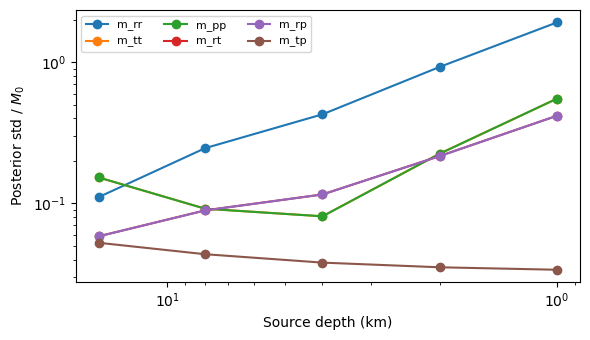

In [3]:
around = geometries["8 around"]
depths_km = [15.0, 8.0, 4.0, 2.0, 1.0]
depth_covariances = {depth_km: posterior_covariance(
    kernels_15_km["8 around"] if depth_km == 15.0 else sensitivity_kernels(around, depth_km), around)
    for depth_km in depths_km}
depth_widths = {depth_km: relative_widths(covariance) for depth_km, covariance in depth_covariances.items()}


def vertical_horizontal_correlation(covariance):
    '''Posterior correlation of m_rr with m_tt + m_pp.'''
    horizontal = np.array([0, 1, 1, 0, 0, 0])
    return (covariance[0] @ horizontal) / np.sqrt(covariance[0, 0] * (horizontal @ covariance @ horizontal))


print(f"{'depth (km)':20s}" + "".join(f"{component:>8s}" for component in COMPONENTS) + f"{'corr':>8s}")
for depth_km, widths in depth_widths.items():
    print(f"{depth_km:<20.0f}" + "".join(f"{width:8.3f}" for width in widths)
          + f"{vertical_horizontal_correlation(depth_covariances[depth_km]):8.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
for index, component in enumerate(COMPONENTS):
    ax.plot(depths_km, [depth_widths[depth_km][index] for depth_km in depths_km], "o-", label=component)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Source depth (km)")
ax.set_ylabel("Posterior std / $M_0$")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()
for index in (0, 3, 4):
    assert depth_widths[1.0][index] > 3 * depth_widths[15.0][index]
assert vertical_horizontal_correlation(depth_covariances[1.0]) > 0.95
assert abs(vertical_horizontal_correlation(depth_covariances[15.0])) < 0.5

## Non-double-couple mass

The source is now a double couple (strike 30°, dip 60°, rake −80°) plus an isotropic expansion of half its scalar moment, which puts it at $\gamma = 0°$, $\delta \approx 31°$ on the lune. For three settings we draw 20 000 moment tensors from the posterior and ask how much posterior mass lies where:

- $\delta > 10°$: an expansion;
- $\delta < -10°$: a contraction.

We also report the median Kagan angle to the true tensor. Reading the posterior as mass rather than as a median matters here: a posterior median can sit near the truth while a large part of the mass says the opposite.

true source: gamma 0.0 deg, delta 31.5 deg


setting                     P(delta > 10)  P(delta < -10)  median Kagan (deg)
15 km, 8 around                      1.00            0.00                 4.4


1 km, 8 around                       0.62            0.23                20.9
15 km, 3 in a 20 deg arc             0.97            0.00                 7.7


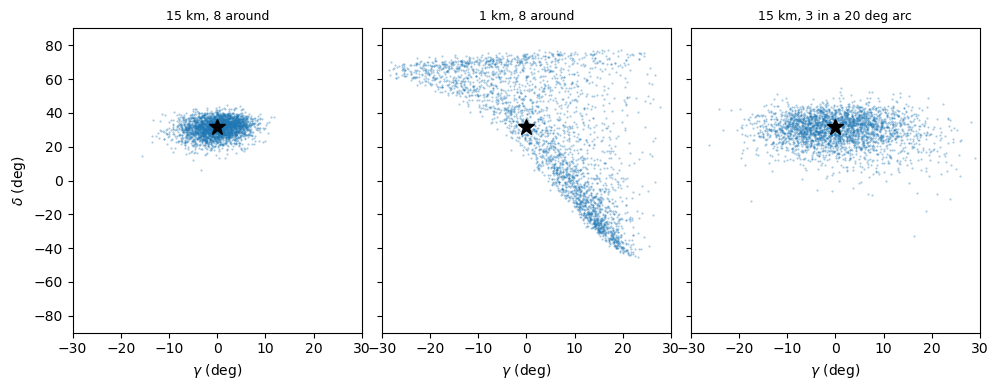

In [4]:
double_couple = from_pyrocko(pmt.MomentTensor(strike=30, dip=60, rake=-80, scalar_moment=SCALAR_MOMENT_NM))
true_moment_tensor = double_couple + 0.5 * SCALAR_MOMENT_NM * np.array([1, 1, 1, 0, 0, 0])
true_gamma_deg, true_delta_deg = mts6_to_gamma_delta(true_moment_tensor.reshape(1, -1))
print(f"true source: gamma {np.round(true_gamma_deg[0], 1) + 0.0:.1f} deg, delta {true_delta_deg[0]:.1f} deg")

settings = {
    "15 km, 8 around": posterior_covariance(kernels_15_km["8 around"], around),
    "1 km, 8 around": depth_covariances[1.0],
    "15 km, 3 in a 20 deg arc": posterior_covariance(kernels_15_km["3 in a 20 deg arc"], geometries["3 in a 20 deg arc"]),
}
standard_normal_draws = np.random.default_rng(0).standard_normal((20000, 6))
lune_draws, expansion_mass = {}, {}
print(f"{'setting':26s}{'P(delta > 10)':>15s}{'P(delta < -10)':>16s}{'median Kagan (deg)':>20s}")
for name, covariance in settings.items():
    draws = true_moment_tensor + standard_normal_draws @ np.linalg.cholesky(covariance).T
    gamma_deg, delta_deg = mts6_to_gamma_delta(draws)
    kagan_deg = kagan_batch(draws, np.tile(true_moment_tensor, (len(draws), 1)))
    lune_draws[name] = (gamma_deg, delta_deg)
    expansion_mass[name] = np.mean(delta_deg > 10)
    print(f"{name:26s}{expansion_mass[name]:15.2f}{np.mean(delta_deg < -10):16.2f}{np.median(kagan_deg):20.1f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
for ax, (name, (gamma_deg, delta_deg)) in zip(axes, lune_draws.items()):
    ax.plot(gamma_deg[:3000], delta_deg[:3000], ".", ms=1, alpha=0.4)
    ax.plot(true_gamma_deg, true_delta_deg, "k*", ms=12)
    ax.set_xlim(-30, 30)
    ax.set_ylim(-90, 90)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel(r"$\gamma$ (deg)")
axes[0].set_ylabel(r"$\delta$ (deg)")
plt.tight_layout()
plt.show()
assert expansion_mass["15 km, 8 around"] > expansion_mass["1 km, 8 around"]

At 15 km with stations all around, essentially all of the posterior mass lies on the expansion side of the lune. At 1 km depth the same stations and noise leave a large share of the mass on the contraction side, even though the true source expands: shallow sources cannot resolve the isotropic part at these periods. A narrow arc of stations mainly widens the orientation (the Kagan angle) and keeps most of the isotropic information.